In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import classification_report, roc_auc_score

# Load the cleaned dataset
df = pd.read_csv('training_data_temporal_corrected.csv', low_memory=False)

# Drop rows where the target is missing
df = df.dropna(subset=['target']).copy()
df['target'] = df['target'].astype(int)

print(f"Data loaded successfully. Total eligible interactions: {len(df)}")

Data loaded successfully. Total eligible interactions: 71387


In [6]:
# First, let's list the features we actually care about
features_to_use = [
    'num_pages', 
    'average_rating', 
    'publication_year',
    'previous_interactions', 
    'previous_conversions_90d',
    'user_conversion_rate_90d', 
    'user_avg_rating', 
    'user_avg_pages_read',
    'num_canonical_genres'
]

# Make sure we only check columns that exist in the file
actual_features = [col for col in features_to_use if col in df.columns]

# Print out the count of missing (NaN) values for each column
print("--- Missing Values Count Before Filling ---")
print(df[actual_features].isnull().sum())

--- Missing Values Count Before Filling ---
num_pages                       0
average_rating                  3
publication_year            10453
previous_interactions           0
previous_conversions_90d        0
user_conversion_rate_90d    13525
user_avg_rating             27336
user_avg_pages_read         22413
num_canonical_genres            0
dtype: int64


In [7]:
# print("Total columns in df:", len(df.columns))
# print(df.columns.tolist())

Total columns in df: 40
['user_id', 'book_id', 'is_read', 'rating', 'date_added', 'date_updated', 'read_at', 'started_at', 'reading_duration_days', 'title', 'author_ids', 'author_names', 'average_rating', 'publication_year', 'description', 'genres', 'num_pages', 'original_title', 'original_publication_year', 'target', 'genres_list', 'cleaned_genres', 'normalized_genres', 'canonical_genres', 'num_canonical_genres', 'author_id_list', 'primary_author_id', 'canonical_genres_list', 'publication_year_final', 'previous_interactions', 'previous_eligible', 'previous_conversions_90d', 'user_conversion_rate_90d', 'user_avg_rating', 'user_avg_pages_read', 'genre_conversion_rates', 'author_conversion_rates', 'page_group_conversion_rates', 'book_rating_group_conversion_rates', 'publication_year_group_conversion_rates']


In [8]:
# 1. Fix missing Goodreads metadata
df['publication_year'] = df['publication_year'].fillna(df['publication_year'].median())
df['average_rating'] = df['average_rating'].fillna(df['average_rating'].mean())

# 2. Fix "Cold Start" users who have no reading history yet
behavioral_cols = [
    'user_conversion_rate_90d', 
    'user_avg_rating', 
    'user_avg_pages_read'
]
df[behavioral_cols] = df[behavioral_cols].fillna(0.0)

# Verify everything is perfectly clean!
print("--- Missing Values After Cleaning ---")
print(df[actual_features].isnull().sum())

--- Missing Values After Cleaning ---
num_pages                   0
average_rating              0
publication_year            0
previous_interactions       0
previous_conversions_90d    0
user_conversion_rate_90d    0
user_avg_rating             0
user_avg_pages_read         0
num_canonical_genres        0
dtype: int64


model training

LOGISTIC REGRESSION

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# 1. Define Features (X) and Target (y)
X = df[actual_features]
y = df['target'].astype(int)

# 2. Train-Test Split
# We give the model 80% of the data to learn from, and hide 20% to test it like an exam.
# 'stratify=y' ensures the 80/20 split keeps the exact same ratio of read vs. unread books.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Scale the features 
# This squashes all numbers to a similar scale so big numbers (like 500 pages) 
# don't overpower small decimals (like a 0.2 conversion rate).
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Train the Baseline Logistic Regression Model
# 'class_weight=balanced' tells the model to pay extra attention to the minority class
print("Training Logistic Regression...")
log_model = LogisticRegression(class_weight='balanced', random_state=42)
log_model.fit(X_train_scaled, y_train)

# 5. Evaluate it!
y_pred = log_model.predict(X_test_scaled)
y_prob = log_model.predict_proba(X_test_scaled)[:, 1]

print("\n--- Logistic Regression Results ---")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

Training Logistic Regression...

--- Logistic Regression Results ---
              precision    recall  f1-score   support

           0       0.82      0.71      0.76      9546
           1       0.54      0.69      0.61      4732

    accuracy                           0.71     14278
   macro avg       0.68      0.70      0.69     14278
weighted avg       0.73      0.71      0.71     14278

ROC-AUC Score: 0.7813


RANDOM FOREST

In [10]:
from sklearn.ensemble import RandomForestClassifier

print("Training Random Forest...")
# n_estimators=100 creates 100 decision trees and averages their results
# n_jobs=-1 uses all your computer's processor cores to train faster
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

print("\n--- Random Forest Results ---")
print(classification_report(y_test, y_pred_rf))
print(f"Random Forest ROC-AUC Score: {roc_auc_score(y_test, y_prob_rf):.4f}")

Training Random Forest...

--- Random Forest Results ---
              precision    recall  f1-score   support

           0       0.77      0.86      0.82      9546
           1       0.64      0.49      0.55      4732

    accuracy                           0.74     14278
   macro avg       0.71      0.68      0.69     14278
weighted avg       0.73      0.74      0.73     14278

Random Forest ROC-AUC Score: 0.7874


XGBOOST

In [11]:
import xgboost as xgb

print("Training XGBoost...")
# XGBoost calculates class imbalance slightly differently using scale_pos_weight
ratio = float(np.sum(y_train == 0)) / np.sum(y_train == 1)

xgb_model = xgb.XGBClassifier(
    n_estimators=100, 
    learning_rate=0.1, 
    scale_pos_weight=ratio, 
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb_model.fit(X_train_scaled, y_train)

y_pred_xgb = xgb_model.predict(X_test_scaled)
y_prob_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

print("\n--- XGBoost Results ---")
print(classification_report(y_test, y_pred_xgb))
print(f"XGBoost ROC-AUC Score: {roc_auc_score(y_test, y_prob_xgb):.4f}")

Training XGBoost...


C:\Users\emrid\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [20:01:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- XGBoost Results ---
              precision    recall  f1-score   support

           0       0.85      0.70      0.77      9546
           1       0.55      0.75      0.64      4732

    accuracy                           0.72     14278
   macro avg       0.70      0.72      0.70     14278
weighted avg       0.75      0.72      0.72     14278

XGBoost ROC-AUC Score: 0.8018


Save the Model Artifacts

In [12]:
import joblib

# Save the trained XGBoost model
joblib.dump(xgb_model, 'xgboost_conversion_model.pkl')

# Save the scaler so candidate books are scaled exactly like the training data
joblib.dump(scaler, 'feature_scaler.pkl')

print("Model and Scaler successfully saved for Backend Integration!")

Model and Scaler successfully saved for Backend Integration!


FEATURE INTEGRATION

feature integration

--- XGBoost Feature Importance ---


,Feature,Importance
5,user_conversion_rate_90d,0.600138
3,previous_interactions,0.141286
7,user_avg_pages_read,0.055673
4,previous_conversions_90d,0.046134
6,user_avg_rating,0.038956
2,publication_year,0.035697
0,num_pages,0.031179
8,num_canonical_genres,0.027142
1,average_rating,0.023796


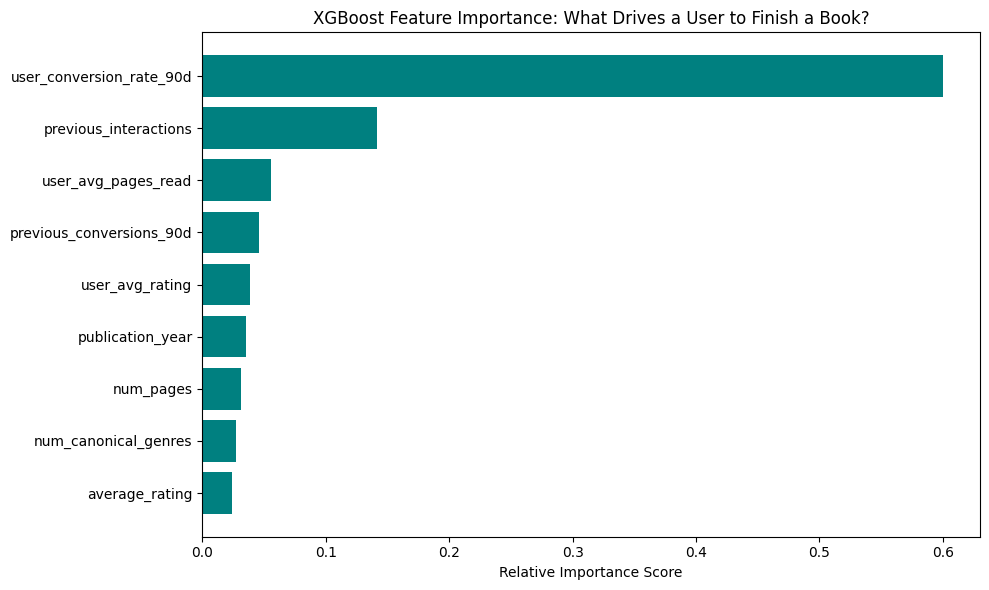

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

print("--- XGBoost Feature Importance ---")

# Get the raw importance scores from your trained XGBoost model
importance_scores = xgb_model.feature_importances_

# Create a clean table matching your feature names to their scores
feature_importance_df = pd.DataFrame({
    'Feature': actual_features,
    'Importance': importance_scores
}).sort_values(by='Importance', ascending=False)

display(feature_importance_df)

# Plot the importances as a horizontal bar chart
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='teal')
plt.gca().invert_yaxis()  # Puts the most important feature at the top
plt.title('XGBoost Feature Importance: What Drives a User to Finish a Book?')
plt.xlabel('Relative Importance Score')
plt.tight_layout()
plt.show()

In [17]:
import joblib
import pandas as pd

# 1. Load your Looknew AI components
model = joblib.load('xgboost_conversion_model.pkl')
scaler = joblib.load('feature_scaler.pkl')

# 2. Simulate a dummy payload from the frontend with all 9 features
# Added '3' at the end to represent num_canonical_genres
dummy_data = pd.DataFrame(
    [[350, 4.2, 2015, 10, 2, 0.20, 3.8, 310, 3]], 
    columns=actual_features
)

# 3. Scale and Predict just like a live server
scaled_data = scaler.transform(dummy_data)
probability = model.predict_proba(scaled_data)[0][1]

print(f"API Response: The user has a {probability * 100:.1f}% chance of reading this book.")

API Response: The user has a 58.9% chance of reading this book.
